In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
import astropy
from astropy.visualization import hist
from sklearn.neighbors import KernelDensity

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_13876\224906477.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


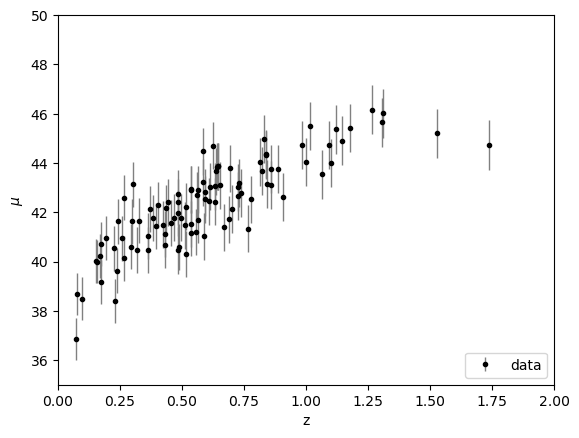

In [3]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [5]:
X_grid = np.linspace(0, 2, 100).reshape(-1,1)
z_fit = z_sample[:, None]

In [7]:
kernel1 = ConstantKernel(1, (1e-1, 1e1))* kernels.RBF(length_scale = 10.0, length_scale_bounds = (1e-2, 1e2))
gp1 = GaussianProcessRegressor(kernel=kernel1, alpha= dmu**2)
gp1.fit(z_fit, mu_sample)
mu_predict, sigma_predict = gp1.predict(X_grid, return_std=True) 

C:\Users\User\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


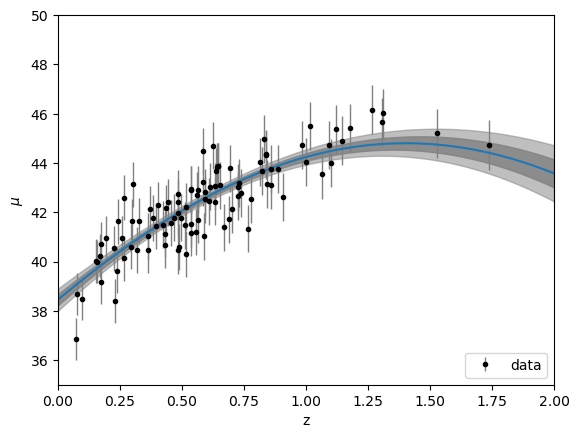

In [9]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(X_grid, mu_predict)
plt.xlabel(r"z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

upper1 = mu_predict + sigma_predict
lower1 = mu_predict - sigma_predict
upper2 = mu_predict + 2*sigma_predict
lower2 = mu_predict - 2*sigma_predict
plt.fill_between(np.linspace(0, 2, 100), lower2, upper2,color="grey", alpha=0.5)
plt.fill_between(np.linspace(0, 2, 100), lower1, upper1,color="grey", alpha=0.8)

In [47]:
#function 
def kde_sklearn(data, bandwidth = 0.5, kernel="gaussian"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(X_grid) # sklearn returns log(density)
    return np.exp(log_pdf)

def cloned_data(data, bandwidth = 0.5, kernel="gaussian"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_fit = kde_skl.fit(data[:, np.newaxis])
    cloned = kde_fit.sample(1000) #ten times more 
    return cloned

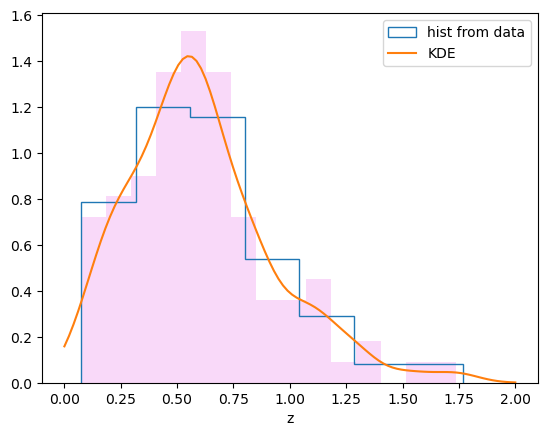

In [49]:
astropy.visualization.hist(z_sample, bins="scott", histtype="step",density=True, label="hist from data")
plt.hist(z_sample,bins=15, alpha=0.30, color="violet", density=True) 

PDF_z = kde_sklearn(z_sample,bandwidth=0.1,kernel="gaussian")
plt.plot(X_grid,PDF_z, label="KDE") 
plt.xlabel("z")
plt.legend()

In [51]:
#print(PDF_z)
z_cloned = cloned_data(z_sample,bandwidth=0.15,kernel="gaussian")
print(len(z_cloned))
#print(z_cloned)

1000


(array([0.01617699, 0.04853098, 0.12132744, 0.36398232, 0.73605314,
        0.79267262, 1.13238945, 1.42357531, 1.11621246, 0.84120359,
        0.39633631, 0.39633631, 0.23456639, 0.22647789, 0.09706195,
        0.08088496, 0.01617699, 0.02426549, 0.01617699, 0.        ,
        0.0080885 ]),
 array([-0.35365351, -0.23002114, -0.10638876,  0.01724362,  0.140876  ,
         0.26450837,  0.38814075,  0.51177313,  0.63540551,  0.75903788,
         0.88267026,  1.00630264,  1.12993501,  1.25356739,  1.37719977,
         1.50083215,  1.62446452,  1.7480969 ,  1.87172928,  1.99536165,
         2.11899403,  2.24262641]),
 [<matplotlib.patches.Polygon at 0x294569faae0>])

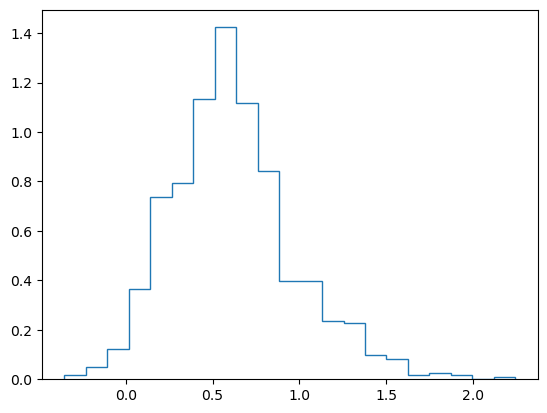

In [53]:
astropy.visualization.hist(z_cloned, bins="scott", histtype="step",density=True, label="hist from data")

In [63]:
kernel2 = ConstantKernel(1, (1e-3, 1e3))* kernels.RBF(length_scale = 10.0, length_scale_bounds = (1e-2, 1e2))
gp2 = GaussianProcessRegressor(kernel=kernel2, alpha= dmu**2)
gp2.fit(z_sample.reshape(-1,1), mu_sample)
mu_pred, sigma_pred = gp2.predict(z_cloned.reshape(-1,1), return_std=True) 
mu_pred_gpr = np.random.normal(loc=mu_pred, scale=sigma_pred, size = len(mu_pred))

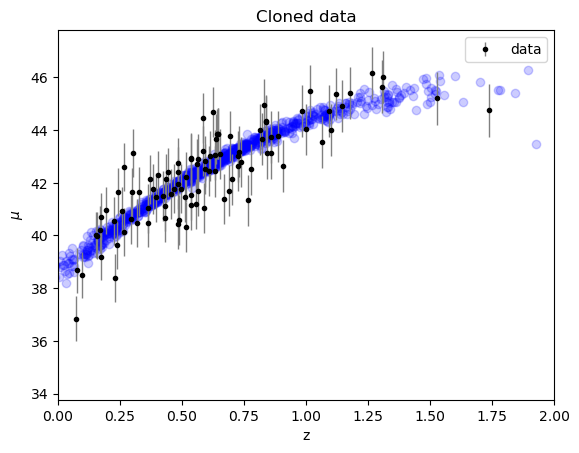

In [71]:
plt.scatter(z_cloned, mu_pred_gpr, alpha=0.2, color="blue")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.title("Cloned data")
plt.xlim(0,2)
plt.legend()